# Orphan gamma-ray bursts
Marina Masson 2021

## 1. Light curve

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import math
import scipy
import random

from math import radians
import matplotlib.cm as cm

### 1.1 Jet break transition

Jet break transition takes place at :
$$ t_{jet} = 0.7(1+z)(\frac{E_{51}}{n_0})^{1/3}(\frac{\theta_j}{0.1})^2 $$
$ t_{jet} $ in days. 

The jet is considered homogeneous.

Parameters :
- Redshift $ z = 1 $,
- Jet energy $ E = 10^{47} $ to $ 10^{54} $ erg,
- Ambiant particle number density $ n_0 = 0.1 $ to $ 1 $ cm$ ^{-3} $,
- Opening angle $ \theta_{jet} = 3° $ to $ 10° $.

Text(0, 0.5, 'Jet break transition (days)')

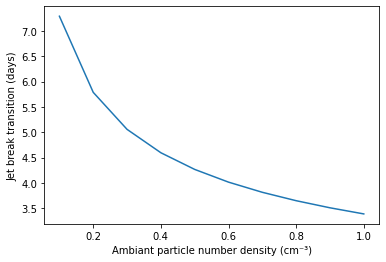

In [2]:
z = 1
n0 = np.linspace(0.1,1,10)
E = 0.5 #in units of 10⁵¹
theta_j = 10*np.pi/180

t_jet = (0.7*(1+z)*(E/n0)**(1/3)*((theta_j)/0.1)**2)

plt.plot(n0, t_jet)
plt.xlabel('Ambiant particle number density (cm⁻³)')
plt.ylabel('Jet break transition (days)')

Text(0, 0.5, 'Jet break transition (days)')

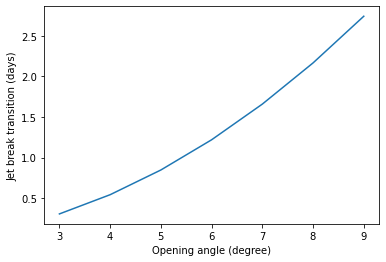

In [3]:
z = 1
n0 = 1
E = 0.5 #in units of 10⁵¹
theta_j = np.arange(3,10)

t_jet = (0.7*(1+z)*(E/n0)**(1/3)*((theta_j*np.pi/180)/0.1)**2)

plt.plot(theta_j, t_jet)
plt.xlabel('Opening angle (degree)')
plt.ylabel('Jet break transition (days)')

Text(0, 0.5, 'Jet break transition (days)')

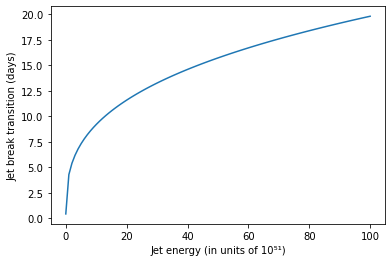

In [4]:
z = 1
n0 = 1
E = np.linspace(0.001,100,100) #in units of 10⁵¹
theta_j = 10*np.pi/180

t_jet = (0.7*(1+z)*(E/n0)**(1/3)*(theta_j/0.1)**2)

plt.plot(E, t_jet)
plt.xlabel('Jet energy (in units of 10⁵¹)')
plt.ylabel('Jet break transition (days)')

### 1.2 Maximal emission

Due to relativistic beaming, an observer located at $\theta_{obs} > \theta_{jet}$ will (pratically) observe the afterglow emission only at $t_\theta$ when $\gamma = \theta_{obs}^{-1}$ :
$$ t_\theta = A (\frac{\theta_{obs}}{\theta_j})^2 t_{jet} $$

Parameters : 
- $A = 1$ (order of unity),
- $\theta_{obs} = 10°$ to $90°$. 

t_theta(45°) =  68.54321428849657 days


Text(0, 0.5, '$t_\\theta$ (days)')

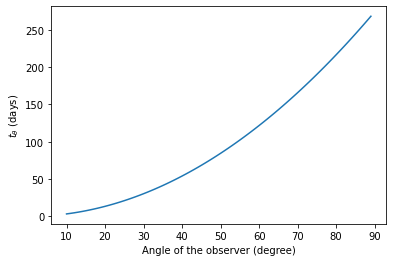

In [5]:
z = 1
A = 1
n0 = 1
E = 0.5 #in units of 10⁵¹
theta_j = 10
theta_obs = np.arange(10,90)


t_jet = 0.7*(1+z)*(E/n0)**(1/3)*((theta_j*np.pi/180)/0.1)**2

t_theta = (A*(theta_obs/theta_j)**2*t_jet)


print('t_theta(45°) = ', A*(45/theta_j)**2*t_jet, 'days') 

plt.plot(theta_obs, t_theta)
plt.xlabel('Angle of the observer (degree)')
plt.ylabel(r'$t_\theta$ (days)')

### 1.3 Cooling frequency 

The cooling frequency is expressed as : 
$$ \nu_c = 3.62 \times 10^{15}(\frac{p-0.98}{p-0.04})^2 10^{(2.2-p)/2} \epsilon_{B,-2}^{-3/2}n_0^{-5/6}E_{50.7}^{-2/3}(1+z)^{-1} $$ 
$\nu_c$ in Hertz. 

Parameters : 
- Power law index of the electrons distribution $p = 2.2$,
- Equipartition parameters : $\epsilon_B = 0.01$,
- Jet energy : $E_{50.7} \approx E_{51} = 0.5$ erg,
- Redshift $z = 1$,
- Ambiant particle number density $ n_0 = 1 $ cm$ ^{-3} $.

In [6]:
z = 1
n0 = 1
E = 0.5 #in units of 10⁵¹
p = 2.2
eB = 1 #in units of 10⁻²

nu_c = 3.62*10**15*((p-0.92)/(p-0.04))**2*10**((2.2-p)/2)*eB**(-3/2)*n0**(-5/6)*E**(-2/3)*(1+z)**(-1)

print('Cooling wavelength is ', 3*10**8/nu_c*10**(9), 'nm.')

Cooling wavelength is  297.3333192463837 nm.


### 1.4 Universal post jet-break light curve

Optical wavelength is between $\approx 400$ and $800$ nm so $\lambda_c < \lambda_{opt}$ which means $\nu_c > \nu_{opt}$. The universal post jet-break light curve is (Nakar, Piran and Granot 2002 : https://arxiv.org/pdf/astro-ph/0204203.pdf): 
$$ F_{\nu<\nu_c}(t) = 170\frac{g_1(p)}{g_1(2.2)}10^{\frac{2.2-p}{4}}\epsilon_{e,-1}^{p-1}\epsilon_{B,-2}^{\frac{p+1}{4}}n_0^{\frac{3-p}{12}}E_{50.7}^{\frac{p+3}{3}}t_{days}^{-p}\nu_{14.7}^{\frac{1-p}{2}}(1+z)^{\frac{p+3}{2}}D_{L,28}^{-2} $$
$F_{\nu<\nu_c}$ expressed in $\mu$Jy ($1$ Jy $= 10^{-26}$ W.m$^{-2}$.Hz$^{-1} = 10^{-23}$ erg.s$^{-1}$.cm$^{-2}$.Hz$^{-1}$).

Parameters : 
- Power law index of the electrons distribution $p = 2.2$,
- Equipartition parameters : $\epsilon_B = 0.01$ and $\epsilon_e = 0.1$,
- Jet energy : $E_{50.7} \approx E_{51} = 0.5$ erg,
- Redshift $z = 1$,
- Ambiant particle number density $ n_0 = 1 $ cm$ ^{-3} $,
- Frequency $\nu$ in the optical interval : $\nu = 400$ THz to $789$ THz ($10^{12}$ Hz),
- Luminosity distance $D_L \approx 10^{29}$ cm.

And :
$$ g_1(p) = 10^{-0.31p}(p-0.04)[(p-2)/(p-1)]^{p-1} $$

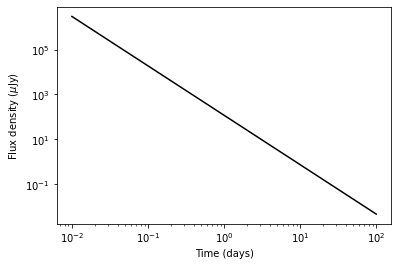

In [7]:
z = 1
n0 = 1
E = 0.5 #in units of 10⁵¹
p = 2.2
eB = 1 #in units of 10⁻²
ee = 1 #in units of 10⁻¹
DL = 1 #in units of 10²⁸
nu = 5 #in units of 10¹⁴


def g1(m):
    return 10**(-0.31*m)*(m-0.04)*((m-2)/(m-1))**(m-1)

t = np.linspace(0.01,100,100)
F = (170*(g1(p)/g1(2.2))*10**((2.2-p)/4)*ee**(p-1)*eB**((p+1)/4)*n0**((3-p)/12)*E**((p+3)/3)*t**(-p)*nu**((1-p)/2)*(1+z)**((p+3)/2)*DL**(-2))

plt.plot(t,F,color='k')

plt.xlabel('Time (days)')
plt.ylabel(r'Flux density ($\mu$Jy)')
plt.xscale('log')
plt.yscale('log')

#### Photometric system of the LSST : 

(We take the mean value)
- u : 320.5–393.5 nm
- g : 401.5–551.9 nm
- r : 552.0–691.0 nm
- i : 691.0–818.0 nm
- z : 818.0–923.5 nm
- y : 923.8–1084.5 nm

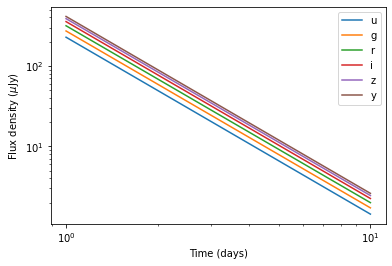

In [8]:
z = 1
n0 = 1
E = 0.5 #in units of 10⁵¹
p = 2.2
eB = 1 #in units of 10⁻²
ee = 1 #in units of 10⁻¹
DL = 1 #in units of 10²⁸

l = [357,481,617,752,866,962] #wavelengths of g,r,i,z,y system
LSST = ['u','g','r','i','z','y']

nu = []

for i in l:
    nu.append(3*10**8/(i*10**(-9))*10**(-14))

def g1(m):
    return 10**(-0.31*m)*(m-0.04)*((m-2)/(m-1))**(m-1)


t = np.linspace(1,10,100)

j = 0
for n in nu:
    F = (170*(g1(p)/g1(2.2))*10**((2.2-p)/4)*ee**(p-1)*eB**((p+1)/4)*n0**((3-p)/12)*E**((p+3)/3)*t**(-p)*(n*10**(-0.7))**((1-p)/2)*(1+z)**((p+3)/2)*DL**(-2))
    plt.plot(t,F,label=LSST[j])
    j = j+1

plt.xlabel('Time (days)')
plt.ylabel(r'Flux density ($\mu$Jy)')
plt.xscale('log')
plt.yscale('log')
plt.legend()

### 1.5 Maximal flux

The maximal flux that an observer at $\theta_{obs}$ will detect :
$$ F_{\nu<\nu_c}(\theta_{obs}) = 620\frac{g_1(p)}{g_1(2.2)}A^{-p}\epsilon_{e,-1}^{p-1}\epsilon_{B,-2}^{\frac{p+1}{4}}n_0^{\frac{p+1}{4}}E_{50.7}\nu_{14.7}^{\frac{1-p}{2}}(1+z)^{\frac{3-p}{2}}D_{L,28}^{-2}\theta_{obs}^{-2p} $$
$F_{\nu<\nu_c}$ in $\mu$Jy.

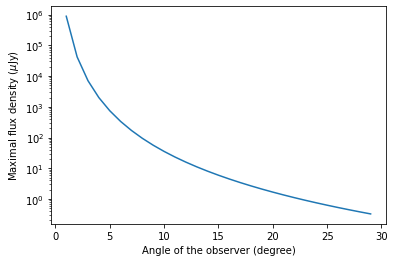

In [9]:
z = 1
n0 = 1
E = 0.5 #in units of 10⁵¹
p = 2.2
eB = 1 #in units of 10⁻²
ee = 1 #in units of 10⁻¹
DL = 1 #in units of 10²⁸
nu = 5 #in units of 10¹⁴
theta_obs = np.arange(1,30)

Fmax = (620*(g1(p)/g1(2.2))*A**(-p)*ee**(p-1)*eB**((p+1)/4)*n0**((p+1)/4)*E*(nu*10**(-0.7))**((1-p)/2)*(1+z)**((3-p)/2)*DL**(-2)*(theta_obs*np.pi/180*10)**(-2*p))
    
plt.plot(theta_obs,Fmax)
plt.xlabel('Angle of the observer (degree)')
plt.ylabel(r'Maximal flux density ($\mu$Jy)')
plt.yscale('log')

### 1.6 Prompt curve

The prompt curve is given by : 
$$ F_\nu(t,\alpha) = a^3F_{\nu,a}(at,\alpha=0) $$

Where $a = \delta(\alpha)/\delta(\alpha=0)<1$, $\delta(\alpha) = [\Gamma(1-\beta cos\alpha)]^{-1}$ the relativistic Doppler factor, $\Gamma = (1-\beta^2)^{-1/2}$ the bulk Lorentz factor and $\beta$ the velocity as a fraction of the speed of light. 

$\Gamma$ is a function of time : $\Gamma = c t^{-3/8}$ and $\beta = (1-\frac{1}{\Gamma^2})^{1/2}$ (Zou, Wu and Dai 2006 : https://arxiv.org/abs/astro-ph/0601292v2). 

Therefore we have :
$$ a = \frac{\delta(\alpha)}{\delta(\alpha=0)} = \frac{1-\beta}{1-\beta cos\alpha} $$

**Parameters :** 

In [10]:
z = 1
n0 = 1
E = 0.5 #in units of 10⁵¹
p = 2.2
eB = 1 #in units of 10⁻²
ee = 1 #in units of 10⁻¹
DL = 1 #in units of 10²⁸
nu = 5 #in units of 10¹⁴
theta_obs = np.pi/4
theta_j = 10*np.pi/180
gamma0 = 100

#### 1.6.1 $\beta$, $\Gamma$ and $a$ functions 

#### $\Gamma$ function

Text(0, 0.5, 'Gamma')

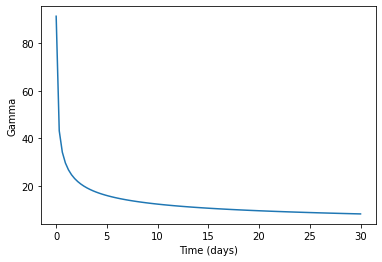

In [11]:
c = 8.9*(1+z)**(3/8)*E**(1/8)*n0**(-1/8)*(theta_j*0.1)**(-1/4)
t0 = (gamma0/c)**(-8/3) #normalisation gamma(t=0) = 100

tmin = 0.01
tmax = 30

t = np.linspace(tmin,tmax,100)

gamma = c*(t+t0)**(-3/8)

plt.plot(t,gamma)

plt.xlabel('Time (days)')
plt.ylabel('Gamma')
#plt.xscale('log')
#plt.yscale('log')

#### $\beta$ function

Text(0, 0.5, 'Beta')

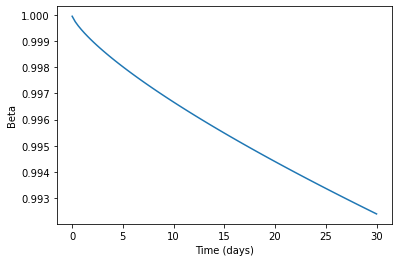

In [12]:
beta = np.sqrt(1-(1/gamma**2))

plt.plot(t,beta)

plt.xlabel('Time (days)')
plt.ylabel('Beta')
#plt.xscale('log')
#plt.yscale('log')

#### Factor $a$ function

Text(0, 0.5, 'Factor a')

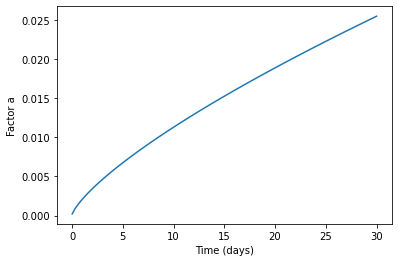

In [13]:
def gamma(c,t):
    return c*(t+t0)**(-3/8)

def beta(c,t):
    return np.sqrt(1-(1/gamma(c,t)**2))

a = (1-beta(c,t))/(1-beta(c,t)*np.cos(theta_obs))

plt.plot(t,a)

plt.xlabel('Time (days)')
plt.ylabel('Factor a')
#plt.xscale('log')
#plt.yscale('log')

#### 1.6.2 Flux density 1

For the flux $ F_{\nu,a}(at,\alpha=0) $, we use the previous expression : $$ F_{\nu<\nu_c}(t) = 170\frac{g_1(p)}{g_1(2.2)}10^{\frac{2.2-p}{4}}\epsilon_{e,-1}^{p-1}\epsilon_{B,-2}^{\frac{p+1}{4}}n_0^{\frac{3-p}{12}}E_{50.7}^{\frac{p+3}{3}}t_{days}^{-p}\nu_{14.7}^{\frac{1-p}{2}}(1+z)^{\frac{p+3}{2}}D_{L,28}^{-2} $$
We replace $t$ in this expression by $at$. 


- **With $c$ from https://ned.ipac.caltech.edu/level5/March04/Piran/Piran7_1.html**

We use for the expression of $c$ : 
$$ \Gamma(t) = (\frac{l^3}{2^34\pi(1-cos(\theta_{obs}))})^{1/8} t^{-3/8} = c t^{-3/8} $$

Considering $k=0$, $k$ being the coefficient of inhomogeneity.

$l$ is the Sedov length ($ \approx 10^{18}$ cm).

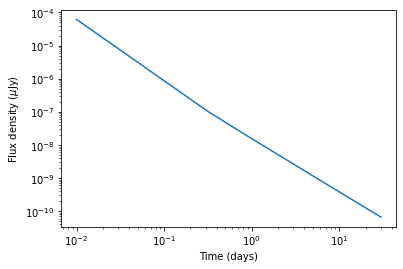

In [14]:
theta_obs = np.pi/6

tmin = 0.01
tmax = 30

c = ((10**18)**3/(8*4*np.pi*(1-np.cos(theta_j))))**(1/8)


def g1(m):
    return 10**(-0.31*m)*(m-0.04)*((m-2)/(m-1))**(m-1)

def gamma(c,t):
    return c*(t+t0)**(-3/8)

def beta(c,t):
    return np.sqrt(1-(1/gamma(c,t)**2))

def a(alpha,t):
    return (1-beta(c,t))/(1-beta(c,t)*np.cos(alpha))

      
t = np.linspace(tmin,tmax,100)
F = (a(theta_obs,t)**3*(170*(g1(p)/g1(2.2))*10**((2.2-p)/4)*ee**(p-1)*eB**((p+1)/4)*n0**((3-p)/12)*E**((p+3)/3)*(a(theta_obs,t)*t)**(-p)*(nu*10**(-0.7))**((1-p)/2)*(1+z)**((p+3)/2)*DL**(-2)))


plt.plot(t,F)

plt.xlabel('Time (days)')
plt.ylabel(r'Flux density ($\mu$Jy)')
plt.xscale('log')
plt.yscale('log')

- **With $c$ from Zou, Wu and Dai (2006) (https://arxiv.org/pdf/astro-ph/0601292v2.pdf)**

We use for the expression of $c$ : 
$$ \Gamma(t) = 8.9 (1+z)^{3/8} E_{52}^{1/8} n_0^{-1/8} \theta_{j,-1}^{-1/4} t^{-3/8} = c t^{-3/8} $$

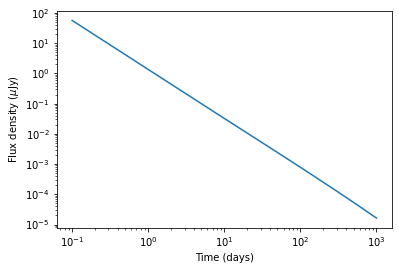

In [15]:
theta_obs = np.pi/4
tmin = 0.1
tmax = 1000


c = 8.9*(1+z)**(3/8)*(E*10**(-1))**(1/8)*n0**(-1/8)*(theta_j*0.1)**(-1/4)


def g1(m):
    return 10**(-0.31*m)*(m-0.04)*((m-2)/(m-1))**(m-1)

def gamma(c,t):
    t0 = (gamma0/c)**(-8/3)
    return c*(t+t0)**(-3/8)

def beta(c,t):
    return np.sqrt(1-(1/gamma(c,t)**2))

def a(c,alpha,t):
    return (1-beta(c,t))/(1-beta(c,t)*np.cos(alpha))


t = np.linspace(tmin,tmax,100)
F = a(c,theta_obs,t)**3*(170*(g1(p)/g1(2.2))*10**((2.2-p)/4)*ee**(p-1)*eB**((p+1)/4)*n0**((3-p)/12)*E**((p+3)/3)*(a(c,theta_obs,t)*t)**(-p)*nu**((1-p)/2)*(1+z)**((p+3)/2)*DL**(-2))


plt.plot(t,F)

plt.xlabel('Time (days)')
plt.ylabel(r'Flux density ($\mu$Jy)')
plt.xscale('log')
plt.yscale('log')

- **With $c$ from Granot et al. (2002) (https://iopscience.iop.org/article/10.1086/340991/pdf) :**

We use $ \Gamma = \theta_j^{-1} (\frac{t}{t_{jet}})^{-3/8} $ if $t<t_{jet}$ and $ \Gamma = \theta_j^{-1} (\frac{t}{t_{jet}})^{-1/2} $ else.

/tmp/ipykernel_202560/400254410.py:23: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(1-(1/gamma(theta, tj, t)**2))


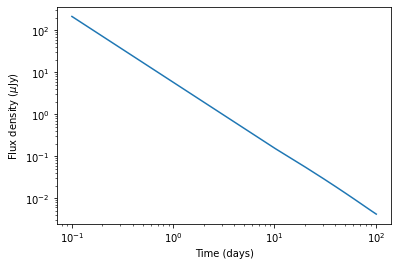

In [16]:
theta_obs = np.pi/4

tmin = 0.1
tmax = 1000

t_jet = (0.7*(1+z)*(E/n0)**(1/3)*(theta_j/0.1)**2)


def g1(m):
    return 10**(-0.31*m)*(m-0.04)*((m-2)/(m-1))**(m-1)

def gamma(theta, tj, t):
    c = theta**(-1)/tj**(-3/8)
    t0 = (gamma0/c)**(-8/3)
    if (t+t0) < tj:
        return c*(t+t0)**(-3/8)
    else:
        c = theta**(-1)/tj**(-1/2)
        t0 = (gamma0/c)**(-2)
        return c*(t+t0)**(-1/2)

def beta(theta, tj, t):
    return np.sqrt(1-(1/gamma(theta, tj, t)**2))

def a(theta, tj, alpha, t):
    return (1-beta(theta, tj, t))/(1-beta(theta, tj, t)*np.cos(alpha))


t = np.linspace(tmin,tmax,100)
F = []

for i in t:
    F.append(a(theta_j,t_jet,theta_obs,i)**3*(170*(g1(p)/g1(2.2))*10**((2.2-p)/4)*ee**(p-1)*eB**((p+1)/4)*n0**((3-p)/12)*E**((p+3)/3)*(a(theta_j,t_jet,theta_obs,i)*i)**(-p)*nu**((1-p)/2)*(1+z)**((p+3)/2)*DL**(-2)))


plt.plot(t,F)

plt.xlabel('Time (days)')
plt.ylabel(r'Flux density ($\mu$Jy)')
plt.xscale('log')
plt.yscale('log')

#### 1.6.3 Flux density 2

For the flux $ F_{\nu,a}(at,\alpha=0) $, we use the new expression (Granot et al. 2002 : https://iopscience.iop.org/article/10.1086/340991/pdf) :
$$ F_\nu = \frac{(1+z)}{4\pi D_L^2}\frac{L'_{\nu'}}{\Gamma^3(1-\beta cos(\theta_{obs}))^3} $$ 
Where $L'_{\nu'}$ is the jet comoving frame spectral luminosity (value set at $10^{50}$ erg/s randomly).


- **With $c = 8.9 (1+z)^{3/8} E_{52}^{1/8} n_0^{-1/8} \theta_{j,-1}^{-1/4}$**

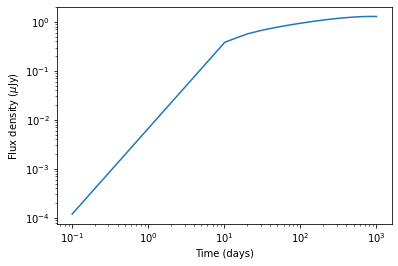

In [17]:
c = 8.9*(1+z)**(3/8)*E**(1/8)*n0**(-1/8)*(theta_j*0.1)**(-1/4)
t0 = (100/c)**(-8/3)

tmin = 0.1
tmax = 1000


def gamma(c,t):
    t0 = (gamma0/c)**(-8/3)
    return c*(t+t0)**(-3/8)

def beta(c,t):
    return np.sqrt(1-(1/gamma(c,t)**2))

def a(c,alpha,t):
    return (1-beta(c,t))/(1-beta(c,t)*np.cos(alpha))

def F_prompt(c, alpha, t): 
    return (1+z)/(4*np.pi*(DL*10**28)**2)*10**56/(gamma(c,t)**3*(1-np.sqrt(1-(1/gamma(c,t)**2))*np.cos(alpha))**3)


t = np.linspace(tmin,tmax,100)
F = []

for i in t:
    F.append(a(c,theta_obs,i)**3*F_prompt(c,0,a(c,theta_obs,i)*i))

plt.plot(t,F)
plt.xlabel('Time (days)')
plt.ylabel(r'Flux density ($\mu$Jy)')
plt.xscale('log')
plt.yscale('log')

- **With $c = \theta_j^{-1} (\frac{1}{t_{jet}})^{-3/8} $ and $ c = \theta_j^{-1} (\frac{1}{t_{jet}})^{-1/2}$**

#### $\Gamma$ function

Text(0, 0.5, 'Gamma')

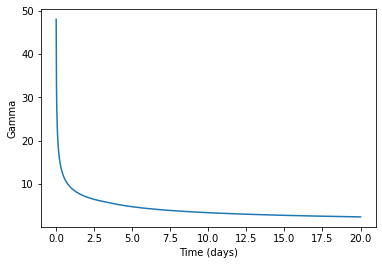

In [18]:
tmin = 0.01
tmax = 20

t_jet = (0.7*(1+z)*(E/n0)**(1/3)*(theta_j/0.1)**2)

t = np.linspace(tmin,tmax,1000)
gamma = []

for i in t:
    c = theta_j**(-1)/t_jet**(-3/8)
    t0 = (gamma0/c)**(-8/3)
    if (i+t0) < t_jet:
        gamma.append(theta_j**(-1)*((i+t0)/t_jet)**(-3/8))
    else:
        c = theta_j**(-1)/t_jet**(-1/2)
        gamma.append(theta_j**(-1)*((i+t0)/t_jet)**(-1/2))      
        
plt.plot(t,gamma)

plt.xlabel('Time (days)')
plt.ylabel('Gamma')
#plt.xscale('log')
#plt.yscale('log')

#### $\beta$ function

Since $\beta$ becomes complex from a value of $t \approx 111-112$ days, we set the value of $\beta$ to $0.001$ (value chosen randomly) after this time. 

Text(0, 0.5, 'Beta')

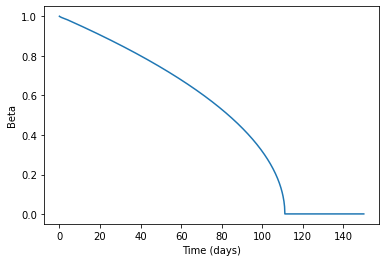

In [19]:
beta = [0]*1000
gamma = []

tmin = 0.001
tmax = 150

t = np.linspace(tmin,tmax,1000)

for i in t:
    c = theta_j**(-1)/t_jet**(-3/8)
    t0 = (gamma0/c)**(-8/3)
    if (i+t0) < t_jet:
        gamma.append(theta_j**(-1)*((i+t0)/t_jet)**(-3/8))
    else:
        c = theta_j**(-1)/t_jet**(-1/2)
        gamma.append(theta_j**(-1)*((i+t0)/t_jet)**(-1/2))

for j in range(1000):
    if (1-(1/gamma[j]**2)) > 0.001:
        beta[j] = np.sqrt(1-(1/gamma[j]**2))
    else:
        beta[j] = 0.001
    #print(gamma[j], beta[j])
    
plt.plot(t,beta)
plt.xlabel('Time (days)')
plt.ylabel('Beta')
#plt.xscale('log')
#plt.yscale('log')

#### Factor $a$ function

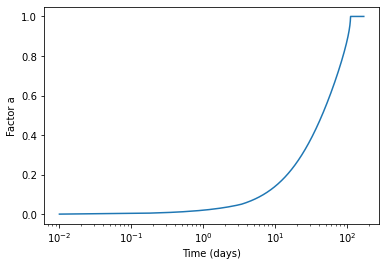

In [20]:
theta_obs = np.pi/4

tmin = 0.01
tmax = 170


def gamma(theta, tj, t):
    c = theta**(-1)/tj**(-3/8)
    t0 = (gamma0/c)**(-8/3)
    if (t+t0) < tj:
        return c*(t+t0)**(-3/8)
    else:
        c = theta**(-1)/tj**(-1/2)
        t0 = (gamma0/c)**(-2)
        return c*(t+t0)**(-1/2)

def beta(theta, tj, t):
    if (1-(1/gamma(theta,tj,t)**2)) > 0.001:
        return np.sqrt(1-(1/gamma(theta,tj,t)**2))
    else:
        return 0.001


t = np.linspace(tmin,tmax,1000)
a = []

for i in t:
    a.append((1-beta(theta_j, t_jet, i))/(1-beta(theta_j, t_jet, i)*np.cos(theta_obs)))
    
plt.plot(t,a)
plt.xlabel('Time (days)')
plt.ylabel('Factor a')
plt.xscale('log')
#plt.yscale('log')

#### Prompt curve

4.264643877013919


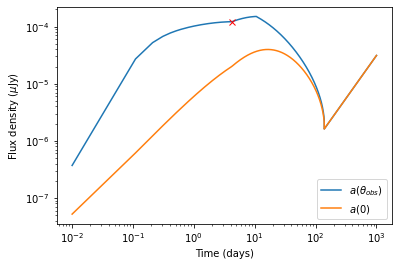

In [21]:
theta_j = 10*np.pi/180
theta_obs = 2*theta_j
E = 1 #in units of 10⁵¹
L_nu = 1*E*10**51
tmin = 0.01
tmax = 1000


t_jet = (0.7*(1+z)*(E/n0)**(1/3)*(theta_j/0.1)**2)
print(t_jet)


def gamma(theta, tj, t):
    c = theta**(-1)/tj**(-3/8)
    t0 = (gamma0/c)**(-8/3)
    if (t+t0) < tj:
        return c*(t+t0)**(-3/8)
    else:
        c = theta**(-1)/tj**(-1/2)
        t0 = (gamma0/c)**(-2)
        return c*(t+t0)**(-1/2)

def beta(theta, tj, t):
    if (1-(1/gamma(theta,tj,t)**2)) > 0.01:
        return np.sqrt(1-(1/gamma(theta,tj,t)**2))
    else:
        return 0.01

def a(theta, tj, alpha, t):
    return (1-beta(theta, tj, t))/(1-beta(theta, tj, t)*np.cos(alpha))

def F_prompt(theta, alpha, tj, t): 
    return (1+z)/(4*np.pi*(DL*10**28)**2)*L_nu/(gamma(theta, tj, t)**3*(1-beta(theta, tj, t)*np.cos(alpha))**3)
    

t = np.linspace(tmin,tmax,10000)
F = []
F0 = []

for i in t:
    F.append(a(theta_j,t_jet,theta_obs,i)**3*F_prompt(theta_j,0,t_jet,a(theta_j,t_jet,theta_obs,i)*i))
    F0.append(a(theta_j,t_jet,theta_obs,i)**3*F_prompt(theta_j,0,t_jet,a(theta_j,t_jet,0,i)*i))

    
F_tjet = a(theta_j,t_jet,theta_obs,t_jet)**3*F_prompt(theta_j,0,t_jet,a(theta_j,t_jet,theta_obs,t_jet)*t_jet)

plt.plot(t,F,label = r'$a(\theta_{obs})$')
plt.plot(t,F0,label = r'$a(0)$')
plt.plot(t_jet,F_tjet, 'rx')

plt.xlabel('Time (days)')
plt.ylabel(r'Flux density ($\mu$Jy)')
plt.xscale('log')
plt.yscale('log')
plt.legend(loc = 'lower right')

#### 1.6.4 Flux density 3

For the flux $ F_{\nu,a}(at,\alpha=0) $, we use the new expressions (Sari, Piran and Narayan 1997 : https://arxiv.org/pdf/astro-ph/9712005.pdf) :

$$ F_\nu = \left\{   \begin{array}{rcl}
& (\nu/\nu_c)^{1/3} F_{\nu,max}&  \nu_c > \nu \\
& (\nu/\nu_c)^{-1/2} F_{\nu,max}&  \nu_m > \nu > \nu_c \\
& (\nu_m/\nu_c)^{-1/2} (\nu/\nu_m)^{-p/2} F_{\nu,max}& \nu > \nu_m 
\end{array}
\right. $$

For the case of *fast cooling*. 

$$ F_\nu = \left\{   \begin{array}{rcl}
& (\nu/\nu_m)^{1/3} F_{\nu,max}&  \nu_m > \nu \\
& (\nu/\nu_m)^{-(p-1)/2} F_{\nu,max}&  \nu_c > \nu > \nu_m \\
& (\nu_c/\nu_m)^{-(p-1)/2} (\nu/\nu_c)^{-p/2} F_{\nu,max}& \nu > \nu_c 
\end{array}
\right. $$

For the case of *slow cooling*. 

There are two hydrodynamical evolutions : adiabatic and radiative. The adiabatic regime corresponds to $\epsilon_e \ll 1$ which is our case here ($\epsilon_e = 0.1$). The adiabatic evolution was also considered in Nakar, Piran and Granot (2002) (https://arxiv.org/pdf/astro-ph/0204203.pdf). Therefore, the parameters of the flux are written : 

$$ \left\{   \begin{array}{rcl}
\nu_c &=& 2.7 \times 10^12 \epsilon_B^{-3/2} E_{52}^{-1/2}n_1^{-1}t_d^{-1/2} \\
\nu_m &=& 5.7 \times 10^14 \epsilon_B^{1/2} \epsilon_e^2 E_{52}^{1/2}t_d^{-3/2} \\
F_{\nu,max} &=& 1.1 \times 10^5 \epsilon_B^{1/2} E_{52} n_1^{1/2}D_{L,28}^{-2}
\end{array}
\right. $$

$\nu_c$ and $\nu_m$ in Hz and $F_{\nu,max}$ in $\mu$Jy.

The transition between fast and slow cooling occurs when $t=t_{trans}$ where $t_{trans} = 210 \epsilon_B^2 \epsilon_e^2 E_{52} n_1$ days.


#### Parameters

The parameters are those used in Granot et al. (2002).

In [22]:
z = 1
E = 80 #in units of 10⁵²
n = 1
theta_j = 5*np.pi/180
A = 1
theta_obs = 2*theta_j
eB = 0.01
ee = 0.1
DL = 1 #10²⁸
p = 2.5
nu = 5*10**14
gamma0 = 100

t = np.linspace(0.1,1000,1000)

#### Prompt curve

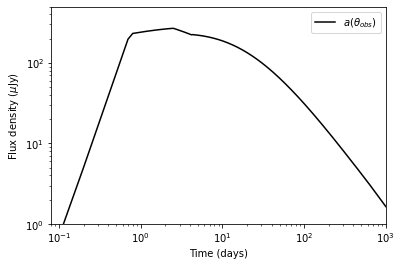

In [23]:
E = 80 #in units of 10⁵²

def nu_c(i, e):
    return 2.7*10**12*eB**(-3/2)*e**(-1/2)*n**(-1)*i**(-1/2)

def nu_m(i, e):
    return 5.7*10**14*eB**(1/2)*ee**2*e**(1/2)*i**(-3/2)

def F_slow(i, nu, f, e): 
    if nu_m(i,e) > nu:
        return ((nu/nu_m(i,e))**(1/3)*f)
    elif nu_c(i,e) > nu and nu > nu_m(i,e):
        return ((nu/nu_m(i,e))**(-(p-1)/2)*f)
    else:
        return ((nu_c(i,e)/nu_m(i,e))**(-(p-1)/2)*(nu/nu_c(i,e))**(-p/2)*f)
    
def F_fast(i, nu, f, e): 
    if nu_c(i,e) > nu:
        return ((nu/nu_c(i,e))**(1/3)*f)
    elif nu_m(i,e) > nu and nu > nu_c(i,e):
        return ((nu/nu_c(i,e))**(-1/2)*f)
    else:
        return ((nu_m(i,e)/nu_c(i,e))**(-1/2)*(nu/nu_m(i,e))**(-p/2)*f)


F = []
t = np.linspace(0.1,1000,10000)

F_max = 1.1*10**5*eB**(1/2)*E*n**(1/2)*DL**(-2)
t_trans = 210*eB**2*ee**2*E*n

for i in t:
    if i < t_trans:
        F.append(a(theta_j,t_jet,theta_obs,i)**3*F_fast(a(theta_j,t_jet,theta_obs,i)*i,nu,F_max,E))
    if i > t_trans:
        F.append(a(theta_j,t_jet,theta_obs,i)**3*F_slow(a(theta_j,t_jet,theta_obs,i)*i,nu,F_max,E))


plt.plot(t,F,label = r'$a(\theta_{obs})$', color = 'k')

plt.xlabel('Time (days)')
plt.ylabel(r'Flux density ($\mu$Jy)')
plt.xscale('log')
plt.yscale('log')
plt.xlim(0.08,1000)
plt.ylim(1,500)
plt.legend()

### 1.7 Light curve in magnitude

To calculate the light curves in magnitude, we use the AB reference (http://www.astronomy.ohio-state.edu/~martini/usefuldata.html). These are for the SDSS (Sloan Digital Sky Survey) filters (u, g, r, i ,z) on the AB system.

The AB system is defined such that a source with $F_\nu = 3.63 \times 10^{-20}$ erg cm$^{-2}$ s$^{-1}$ Hz$^{-1}$ has $mag_{AB} = 0$ in every filter, and in general $mag_{AB} = - 2.5 log(F_\nu) - 48.6$, where $F_\nu$ is in erg cm$^{-2}$ s$^{-1}$ Hz$^{-1}$ ($1 \mu$Jy $=10^{-29}$ erg cm$^{-2}$ s$^{-1}$ Hz$^{-1}$).

The dotted lines represent the median $5\sigma$ limiting magnitudes (for 30 seconds exposures) of the 3 filters ZTF is equipped with : ZTF-g, ZTF-r and ZTF-i (Bellm, E., et al., 2019 : https://arxiv.org/pdf/1902.01932.pdf). Restricting to $\pm 3$ days around new moon, the limiting magnitude increases ($+ 0.3$) and is called *dark-time limiting magnitude*. The authors precise that they did not attempt to match any existing filter bandpasses exactly.

The colors of classical GRBs afterglows ($g-r$ or $r-i$) exhibit no temporal evolution and no redshift dependancy, because these emission mechanisms of optical afterglows, unlike that of other transients, is synchrotron radiation, usually describable by a simple power-law. Here, as we only have access to the public catalog of ZTF, we only have access to the g-band and r-band. 

g-r = 0.3372798777876768 ± 0.014492477375296985


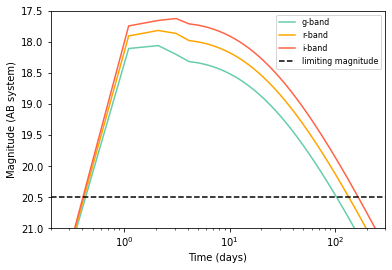

In [24]:
L = [481,617,752]
band = ['g-band', 'r-band', 'i-band']
col = ['mediumaquamarine', 'orange', 'tomato']
#ZTFm = [20.8, 20.6, 19.9]
#ZTFm_nm = [21.1, 20.9, 20.2]

nu = []
for l in L:
    nu.append(3*10**8/(l*10**(-9)))

t = np.linspace(0.1,1000,1000)
    
k=0
for v in nu:
    mag = []
    for i in t:
        if i < t_trans:
            mag.append(-2.5*np.log10((a(theta_j,t_jet,theta_obs,i)**3*F_fast(a(theta_j,t_jet,theta_obs,i)*i,v,F_max,E))*10**(-29))-48.6)
        if i > t_trans:
            mag.append(-2.5*np.log10((a(theta_j,t_jet,theta_obs,i)**3*F_slow(a(theta_j,t_jet,theta_obs,i)*i,v,F_max,E))*10**(-29))-48.6)
    plt.plot(t, mag, color = col[k],label=band[k])
    k += 1

    plt.xlabel('Time (days)')
    plt.ylabel('Magnitude (AB system)')
    plt.xlim(0.2,300)
    plt.ylim(17.5,21)
    plt.gca().invert_yaxis()
    plt.xscale('log')
    
    
plt.axhline(y=20.5, color='black', linestyle='--', label='limiting magnitude')
#plt.axhline(y=20.8, color='black', linestyle=':', label='dark-time limiting magnitude')
#plt.legend(bbox_to_anchor=(1.04,0.5), loc="center left", borderaxespad=0)
plt.legend(prop={'size':8})


dmag = []
for i in t:
    if i < t_trans:
        dmag.append((-2.5*np.log10((a(theta_j,t_jet,theta_obs,i)**3*F_fast(a(theta_j,t_jet,theta_obs,i)*i,nu[0],F_max,E))*10**(-29))-48.6)-(-2.5*np.log10((a(theta_j,t_jet,theta_obs,i)**3*F_fast(a(theta_j,t_jet,theta_obs,i)*i,nu[1],F_max,E))*10**(-29))-48.6))
    if i > t_trans:
        dmag.append((-2.5*np.log10((a(theta_j,t_jet,theta_obs,i)**3*F_slow(a(theta_j,t_jet,theta_obs,i)*i,nu[0],F_max,E))*10**(-29))-48.6)-(-2.5*np.log10((a(theta_j,t_jet,theta_obs,i)**3*F_slow(a(theta_j,t_jet,theta_obs,i)*i,nu[1],F_max,E))*10**(-29))-48.6))

print('g-r =', np.mean(dmag), '±', np.std(dmag))

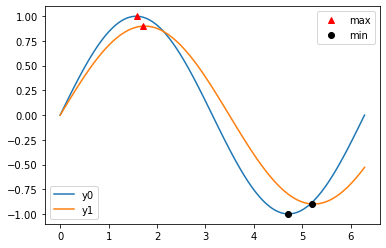

In [25]:
import matplotlib.pyplot as plt
import numpy as np

# Generate data for plotting:  
x = np.linspace(0,2*np.pi,100)
y0 = np.sin(x)
y1 = .9*np.sin(.9*x)
# Find their maxima and minima and store
maxes = np.empty((2,2))
mins = np.empty((2,2))
for k,y in enumerate([y0,y1]):
    maxloc = y.argmax()
    maxes[k] = x[maxloc], y[maxloc]
    minloc = y.argmin()
    mins[k] = x[minloc], y[minloc]

# Instantiate figure and plot
fig = plt.figure()
ax = fig.add_subplot(111)
ax.plot(x,y0, label='y0')
ax.plot(x,y1, label='y1')
# Plot maxima and minima, and keep references to the lines
maxline, = ax.plot(maxes[:,0], maxes[:,1], 'r^')
minline, = ax.plot(mins[:,0], mins[:,1], 'ko')

# Add first legend:  only labeled data is included
leg1 = ax.legend(loc='lower left')
# Add second legend for the maxes and mins.
# leg1 will be removed from figure
leg2 = ax.legend([maxline,minline],['max','min'], loc='upper right')
# Manually add the first legend back
ax.add_artist(leg1)

In [26]:
E = [0.005, 0.05, 0.5, 5, 50] #in units of 10⁵²
L = [481,617,752]

nu = []
for l in L:
    nu.append(3*10**8/(l*10**(-9)))

t = np.linspace(0.1,1000,1000)
    
k=0
for e in E:
    dmag = []
    for i in t:
        if i < t_trans:
            dmag.append((-2.5*np.log10((a(theta_j,t_jet,theta_obs,i)**3*F_fast(a(theta_j,t_jet,theta_obs,i)*i,nu[0],F_max,e))*10**(-29))-48.6)-(-2.5*np.log10((a(theta_j,t_jet,theta_obs,i)**3*F_fast(a(theta_j,t_jet,theta_obs,i)*i,nu[1],F_max,e))*10**(-29))-48.6))
        if i > t_trans:
            dmag.append((-2.5*np.log10((a(theta_j,t_jet,theta_obs,i)**3*F_slow(a(theta_j,t_jet,theta_obs,i)*i,nu[0],F_max,e))*10**(-29))-48.6)-(-2.5*np.log10((a(theta_j,t_jet,theta_obs,i)**3*F_slow(a(theta_j,t_jet,theta_obs,i)*i,nu[1],F_max,e))*10**(-29))-48.6))
        k += 1

    print('g-r =', np.mean(dmag), '±', np.std(dmag), 'pour E = ', e, 'x 10⁵² erg')

g-r = 0.20248273089055027 ± 0.00884784636792498 pour E =  0.005 x 10⁵² erg
g-r = 0.27147761848589075 ± 0.06312571301208326 pour E =  0.05 x 10⁵² erg
g-r = 0.32935785453705263 ± 0.03370712852960725 pour E =  0.5 x 10⁵² erg
g-r = 0.3360041903758362 ± 0.01928444153168195 pour E =  5 x 10⁵² erg
g-r = 0.3371903894206539 ± 0.014886763335451927 pour E =  50 x 10⁵² erg


### 1.8 Test of different parameters

To test the different parameters (angle of the observer, total energy of the jet and frequency of the LSST filters), we use the last flux density tested. 

#### 1.8.1 Influence of the angle of the observer 

We notice that the more off-axis the observer is, the later the emission peaks and the lower the flux at peak is. 

Text(100, 0.03, '$\\theta_j = 5°$')

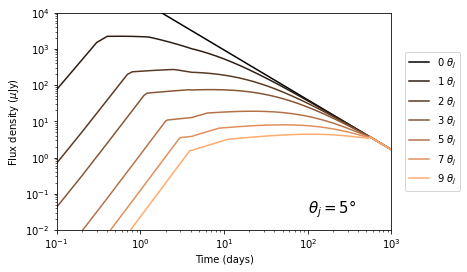

In [27]:
nu = 5*10**14
E = 80 #10⁵²
theta_obs = [0, 1, 2, 3, 5, 7, 9]

t = np.linspace(0.001,1000,10000)

k=0
for theta in theta_obs:
    F=[]
    
    for i in t:
        if i < t_trans:
            F.append(a(theta_j,t_jet,theta*theta_j,i)**3*F_fast(a(theta_j,t_jet,theta*theta_j,i)*i,nu,F_max,E))
        if i > t_trans:
            F.append(a(theta_j,t_jet,theta*theta_j,i)**3*F_slow(a(theta_j,t_jet,theta*theta_j,i)*i,nu,F_max,E))
    plt.plot(t, F, label = r'%i $\theta_{j}$' %theta, color=cm.copper(k/len(theta_obs)))
    k += 1 
    
plt.xlabel('Time (days)')
plt.ylabel(r'Flux density ($\mu$Jy)')
plt.xscale('log')
plt.yscale('log')
plt.xlim(0.1,1000)
plt.ylim(0.01,10000)
plt.legend(bbox_to_anchor=(1.04,0.5), loc="center left", borderaxespad=0)
plt.text(100, 0.03, r'$\theta_j = 5°$',fontsize = 15)

Text(100, 12, '$\\theta_j = 5°$')

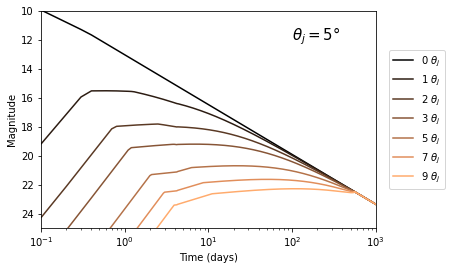

In [28]:
E = 80 #10⁵²
theta_obs = [0, 1, 2, 3, 5, 7, 9]

t = np.linspace(0.001,1000,10000)

k=0
for theta in theta_obs:
    mag=[]
    for i in t:
        if i < t_trans:
            mag.append(-2.5*np.log10((a(theta_j,t_jet,theta*theta_j,i)**3*F_fast(a(theta_j,t_jet,theta*theta_j,i)*i,nu,F_max,E))*10**(-29))-48.6)
        if i > t_trans:
            mag.append(-2.5*np.log10((a(theta_j,t_jet,theta*theta_j,i)**3*F_slow(a(theta_j,t_jet,theta*theta_j,i)*i,nu,F_max,E))*10**(-29))-48.6)
    plt.plot(t, mag, label = r'%i $\theta_{j}$' %theta, color=cm.copper(k/len(theta_obs)))
    k += 1 
    
plt.xlabel('Time (days)')
plt.ylabel('Magnitude')
plt.xscale('log')
plt.gca().invert_yaxis()
plt.xlim(0.1,1000)
plt.ylim(25,10)
plt.legend(bbox_to_anchor=(1.04,0.5), loc="center left", borderaxespad=0)
plt.text(100, 12, r'$\theta_j = 5°$',fontsize = 15)

#### 1.8.2 Influence of the total energy of the jet

We notice that, given the limiting magnitude of ZTF, we need an energy for the jet of at least $10^{52}$ erg to observe the afterglow. 

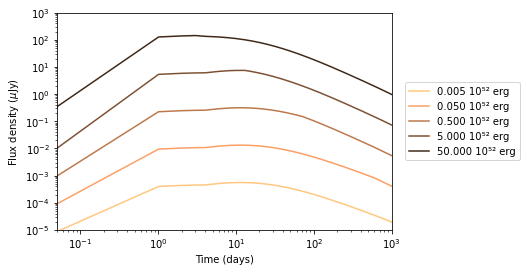

In [29]:
theta_obs = 2*theta_j
nu = 5*10**14
E = [0.005, 0.05, 0.5, 5, 50] #in units of 10⁵²
    
t = np.linspace(0.01,1000,1000)

k = 0
for e in E:
    F=[]
    F_max = 1.1*10**5*eB**(1/2)*e*n**(1/2)*DL**(-2)
    t_trans = 210*eB**2*ee**2*e*n
    for i in t:
        if i < t_trans:
            F.append(a(theta_j,t_jet,theta_obs,i)**3*F_fast(a(theta_j,t_jet,theta_obs,i)*i,nu,F_max,e))
        if i > t_trans:
            F.append(a(theta_j,t_jet,theta_obs,i)**3*F_slow(a(theta_j,t_jet,theta_obs,i)*i,nu,F_max,e))
    plt.plot(t, F, label = '%.3f 10⁵² erg' %e, color=cm.copper((len(E)-k)/len(E)))
    k += 1
    
    
plt.xlabel('Time (days)')
plt.ylabel(r'Flux density ($\mu$Jy)')
plt.xscale('log')
plt.yscale('log')
plt.xlim(0.05,1000)
plt.ylim(0.00001,1000)
plt.legend(bbox_to_anchor=(1.04,0.5), loc="center left", borderaxespad=0)

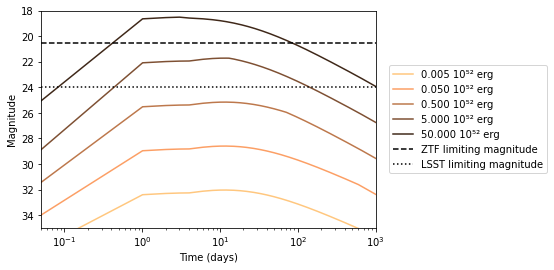

In [30]:
theta_obs = 2*theta_j
nu = 5*10**14
E = [0.005, 0.05, 0.5, 5, 50] #in units of 10⁵²
    
t = np.linspace(0.01,1000,1000)

k = 0
for e in E:
    mag=[]
    F_max = 1.1*10**5*eB**(1/2)*e*n**(1/2)*DL**(-2)
    t_trans = 210*eB**2*ee**2*e*n
    for i in t:
        if i < t_trans:
            mag.append(-2.5*np.log10((a(theta_j,t_jet,theta_obs,i)**3*F_fast(a(theta_j,t_jet,theta_obs,i)*i,nu,F_max,e))*10**(-29))-48.6)
        if i > t_trans:
            mag.append(-2.5*np.log10((a(theta_j,t_jet,theta_obs,i)**3*F_slow(a(theta_j,t_jet,theta_obs,i)*i,nu,F_max,e))*10**(-29))-48.6)
    plt.plot(t, mag, label = '%.3f 10⁵² erg' %e, color=cm.copper((len(E)-k)/len(E)))
    k += 1
    
plt.axhline(y=20.5, color='black', linestyle='--', label='ZTF limiting magnitude')
plt.axhline(y=24, color='black', linestyle=':', label='LSST limiting magnitude')

plt.xlabel('Time (days)')
plt.ylabel('Magnitude')
plt.xscale('log')
plt.gca().invert_yaxis()
plt.xlim(0.05,1000)
plt.ylim(35,18)
plt.legend(bbox_to_anchor=(1.04,0.5), loc="center left", borderaxespad=0)

#### 1.8.3 Influence of the frequency of the LSST filters

The light curve is plotted for all the filters used by LSST, in which are included those of ZTF. We notice that after the peak, the difference between the filters is constant : this is an achromatic break. 

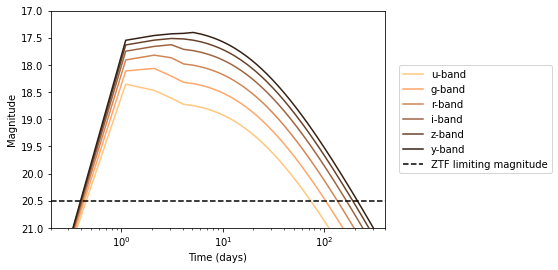

In [31]:
theta_obs = 2*theta_j
E = 80 #10⁵²

L = [357,481,617,752,866,962] #wavelengths of u, g, r, i, z, y system
LSST = ['u-band','g-band','r-band','i-band','z-band','y-band']

nu = []
for l in L:
    nu.append(3*10**8/(l*10**(-9))*10**(-14))

t = np.linspace(0.1,1000,1000)

F_max = 1.1*10**5*eB**(1/2)*E*n**(1/2)*DL**(-2)
t_trans = 210*eB**2*ee**2*E*n

k=0
for v in nu:
    mag=[]
    for i in t:
        if i < t_trans:
            mag.append(-2.5*np.log10((a(theta_j,t_jet,theta_obs,i)**3*F_fast(a(theta_j,t_jet,theta_obs,i)*i,v*10**14,F_max,E))*10**(-29))-48.6)
        if i > t_trans:
            mag.append(-2.5*np.log10((a(theta_j,t_jet,theta_obs,i)**3*F_slow(a(theta_j,t_jet,theta_obs,i)*i,v*10**14,F_max,E))*10**(-29))-48.6)
    plt.plot(t, mag, label = LSST[k], color=cm.copper((len(nu)-k)/len(nu)))
    k += 1

plt.axhline(y=20.5, color='black', linestyle='--', label='ZTF limiting magnitude')

plt.xlabel('Time (days)')
plt.ylabel('Magnitude')
plt.xscale('log')
plt.gca().invert_yaxis()
plt.xlim(0.2,400)
plt.ylim(21,17)
plt.legend(bbox_to_anchor=(1.04,0.5), loc="center left", borderaxespad=0)

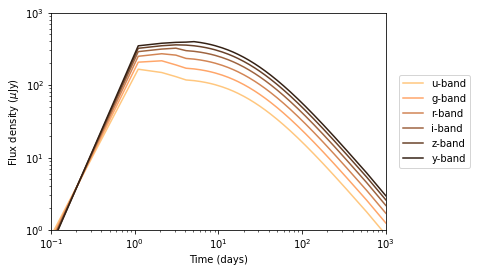

In [32]:
theta_obs = 2*theta_j
E = 80 #10⁵²

L = [357,481,617,752,866,962] #wavelengths of u, g, r, i, z, y system
LSST = ['u-band','g-band','r-band','i-band','z-band','y-band']

nu = []
for l in L:
    nu.append(3*10**8/(l*10**(-9))*10**(-14))

t = np.linspace(0.1,1000,1000)

F_max = 1.1*10**5*eB**(1/2)*E*n**(1/2)*DL**(-2)
t_trans = 210*eB**2*ee**2*E*n

k=0
for v in nu:
    F=[]
    for i in t:
        if i < t_trans:
            F.append(a(theta_j,t_jet,theta_obs,i)**3*F_fast(a(theta_j,t_jet,theta_obs,i)*i,v*10**14,F_max,E))
        if i > t_trans:
            F.append(a(theta_j,t_jet,theta_obs,i)**3*F_slow(a(theta_j,t_jet,theta_obs,i)*i,v*10**14,F_max,E))
    plt.plot(t, F, label = LSST[k], color=cm.copper((len(nu)-k)/len(nu)))
    k += 1
    
    
plt.xlabel('Time (days)')
plt.ylabel(r'Flux density ($\mu$Jy)')
plt.xscale('log')
plt.yscale('log')
plt.xlim(0.1,1000)
plt.ylim(1,1000)
plt.legend(bbox_to_anchor=(1.04,0.5), loc="center left", borderaxespad=0)

### 1.9 Sari and Piran, 1997 : calculations of the flux

The calculations of the flux in Sari and Piran 1997 are based on the book of Rybicki and Lightman 1976. 

#### 1.9.1 Radiation power 

They consider a relativistic particle in motion in a magnetic field $\vec{B}$. The equations of motion are then :
$$ \frac{d}{dt}(\gamma m \vec{v}) = \frac{q}{c}(\vec{v} \times \vec{B}) \\
\frac{d}{dt}(\gamma m c^2) = q \vec{v} \cdot \vec{E} = 0$$

Where $m$ is the mass of an electron. 

The last equation implies that $\gamma = constant$ or that $ |\vec{v}| = constant $. It follows that : 
$$ m \gamma \frac{d\vec{v}}{dt} = \frac{q}{c}\vec{v} \times \vec{B} $$

Separating the velocity components along the field $\vec{v}_{||}$ and in a plane normal to the field $\vec{v}_{\perp}$, we have : 
$$ \frac{d\vec{v}_{||}}{dt} = 0, \quad \frac{d\vec{v}_{\perp}}{dt} = \frac{q}{\gamma m c}\vec{v}_{\perp} \times \vec{B} $$

It follows that $\vec{v}_{||} = constant$ and since the total $\vec{v}_{||} = constant$, also $\vec{v}_{\perp} = constant$. It corresponds to a helical motion of the particle, with a frequency of rotation $\omega_B = \frac{qB}{\gamma m c}$.

The power or a relativistic particle is :
$$ P = \frac{2q^2}{3c^3}\gamma^4(a^2_{\perp} + \gamma^2 a^2_{||}) $$

Then we have :
$$ P = \frac{2q^2}{3c^3}\gamma^4\frac{q^2B^2}{\gamma^2 m^2 c^2}v^2_\perp = \frac{2}{3}r_0^2c\beta^2_\perp\gamma^2B^2 $$

Considering an isotropic distribution of velocities, we have to average this formula over all angles for a given speed $\beta$. Let $\alpha$ be the angle between field and velocity :
$$\langle \beta^2_\perp \rangle = \frac{\beta^2}{4\pi} \int sin^2\alpha d\Omega = \frac{2\beta^2}{3} $$

Finally, we have :
$$ P = \frac{4}{3}\sigma_Tc \beta^2\gamma^2 \frac{B^2}{8\pi} $$
Where $\sigma_T = \frac{8\pi r_0^2}{3}$ is the Thomson cross section.

**Note :** It seems that $\beta$ is called $\gamma_e$ in Sari and Piran 1997.

The peak power occurs at $\nu(\gamma_e)$, where it has the approximate value : 
$$ P_{\nu,max} \approx \frac{P(\gamma_e)}{\nu(\gamma_e)} = \frac{m c^2 \sigma_T}{3q}\gamma B $$

#### 1.9.2 Characteristic frequency $\nu(\gamma_e)$

The frequency of rotation is :
$$ \omega_B = \frac{qB}{\gamma m c} $$

It follows that : 
$$ \nu_B = \frac{qB}{2\pi \gamma mc} $$

To transform the results from the frame of the shocked fluid to the frame of the observer, the factor $\gamma^2$ is introduced (is $\gamma_e^2$ introduced for the same reason ?) :

$$ \nu(\gamma_e) = \gamma \nu_g = \gamma \gamma_e^2 \frac{qB}{2\pi mc} $$ 


#### 1.9.3 Other relevant quantities

We assume that electrons are accelerated in the shock to a power law distribution of Lorentz factor $\gamma_e$ :
$$ N(\gamma_e)d\gamma_e \propto \gamma_e^{-p}d\gamma_e $$

Where $\gamma_e \ge \gamma_m$, $\gamma_m$ being the minimum Lorentz factor.

If we assume that $\epsilon_e$ is the constant fraction of energy going into the electrons, then we have (taking $p = 2.5$) : 
$$ \gamma_m \cong 610 \epsilon_e \gamma $$

And if we assume that $\epsilon_B$ is the constant fraction of energy going into the magnetic energy, then we have : 
$$ B = (32\pi m_p \epsilon_B n)^{1/2}\gamma c $$

The description of the spectral power $P_\nu$ corresponds to the case where the electron does not lose a significant fraction of its energy to radiation. This requires $\gamma_e$ to be less than a critical value $\gamma_c$, above which cooling by synchrotron radiation is significant. The critical electron Lorentz factor $\gamma_c$ is given by the condition $\gamma \gamma_c m_e c^2 = P(\gamma_c)t$ (the moment when all the mass energy of the electron is radiated by synchrotron radiation). Then we have :
$$ \gamma_c = \frac{3m}{16 \epsilon_B \sigma_T m_p c}\frac{1}{t\gamma^3 n} $$

For the adiabatic case, we can find that the Lorentz factor $\gamma$ is :
$$ \gamma(t) \cong (17E/1024\pi nm_pc^5t^3)^{1/8} $$


#### 1.9.4 Characteristic frequencies $\nu_m$ and $\nu_c$

For the adiabatic case, we can find that : 

$$ \nu_c = 2.7 \times 10^{12}\epsilon_B^{-3/2}E_{52}^{-1/2}n_1^{-1}t_d{-1/2} $$
$$ \nu_m = 5.7 \times 10^{14}\epsilon_B^{-3/2}\epsilon_e^2 E_{52}^{1/2}t_d{-1/2} $$

The frequencies being in Hz. 


#### 1.9.5 Maximal flux

We define the maximal flux at distance $D$ from the source as :
$$ F_{\nu,max} = N_eP_{\nu,max}/4\pi D^2 $$

As $R(t) = (17Et/4\pi m_pnc)^{1/4}$ for the adiabatic case and $N_e = \frac{4\pi}{3} R^3n$, we obtain : 

$$ F_{\nu,max} = 1.1 \times 10^5 \epsilon_B^{1/2}E_{52}n_1^{1/2}D_{28}^{-2} $$

The flux is expressed in $\mu$Jy.


#### 1.9.6 Calculation of the Synchrotron Spectrum 

We calculate here the flux for the *slow cooling*, the flux for the *fast cooling* is the same but with $\nu_m$ and $\nu_c$ inverted. The spectrum is divided in 3 segments : $\nu_m > \nu$, $\nu_c > \nu > \nu_m$ and $\nu > \nu_c$.

- $\nu_m > \nu$

According to Rybicki and Lightman 1976, the spectral power $P_\nu$ varies as $\nu^{1/3}$ for $\nu_m > \nu$. As the maximal flux corresponds to $\nu_m$, we can write :
$$ F_\nu \propto P_\nu \propto \nu^{1/3} $$
Therefore :
$$ \frac{F_\nu}{F_{\nu,max}} = (\frac{\nu}{\nu_m})^{1/3} \Rightarrow F_\nu = (\nu/\nu_m)^{1/3}F_{\nu,max}$$

- $\nu_c > \nu > \nu_m$

The energy radiated in the frequency range $\nu$ to $\nu+d\nu$ can be attributed to electrons with energies in the range $E$ to $E+dE$, which we assume to have power-law form $N(E) = \kappa E^{−p}$. Therefore we can write : 
$$ F_\nu = P_\nu N(E) dE $$
With $E \propto \nu^{1/2}$ and $dE \propto \nu^{-1/2}$.

We can write : 
$$ F_\nu \propto \nu^{-(p-1)/2} $$

Finally we have :
$$ \frac{F_\nu}{F_{\nu,max}} = (\frac{\nu}{\nu_m})^{-(p-1)/2} \Rightarrow F_\nu = (\nu/\nu_m)^{-(p-1)/2}F_{\nu,max} $$

- $\nu > \nu_c$

Continuity : $(\frac{\nu_c}{\nu_m})^{-(p-1)/2} = (\frac{\nu_c}{\nu_m})^{-1/2}$ ?

Finally : 
$$ \frac{F_\nu}{F_{\nu,max}} = (\frac{\nu_c}{\nu_m})^{-(p-1)/2}(\frac{\nu}{\nu_c})^{-p/2} \Rightarrow F_\nu = (\nu_c/\nu_m)^{-(p-1)/2}(\nu/\nu_c)^{-p/2}F_{\nu,max} $$

## 2. FINK

GCN Circulars Archive : https://gcn.gsfc.nasa.gov/gcn3_archive.html

FINK Science Portal : http://134.158.75.151:24000/explorer

**GCN objects that are in the FINK Catalog :**

- ZTF21aayokph
- ZTF21aagwbjr
- ZTF21aaeyldq
- ZTF20aaeyldq
- ZTF20acaapwk
- ZTF20abgvabi
- ZTF20aazpphd

To download the data of an object (e.g. ZTF21aayokph here) :

In [33]:
#import requests
#import pandas as pd

## get data for ZTF19acnjwgm
#r = requests.post(
#  'http://134.158.75.151:24000/api/v1/explorer',
#  json={
#    'objectId': 'ZTF21aayokph',
#  }
#)

## Format output in a DataFrame
#pdf = pd.read_json(r.content)

**Doesn't work :(**

### 2.1 Simulation

To simulate some observations of transients, some parameters are chosen randomly according to an uniform distribution : the energy $E$, the opening angle of the jet $\theta_j$ and the angle of the observer $\theta_{obs}$. They are chosen in different ranges :
- $E$ is chosen between $10^{51}$ and $10^{54}$ erg (or 0.1 to 100 erg in units of $10^{52}$).
- $\theta_j$ is chosen between 5 and 15 degrees.
- $\theta_{obs}$ is chosen between 2 and 5 times $\theta_j$.

Depending of these parameters, the light curve in magnitude is plotted with the limiting magnitude of ZTF (and those of LSST). 

To simulate some points detected, an initial time (corresponding to the first observation of a transient) is chosen according to an uniform distribution in the range $0.1 - 100$ days. If this time is chosen after $100$ days, it's in general not detectable.

The following point are plotted every $\Delta t$, $\Delta t$ being chosen according to a Gaussian distribution centered in 3 (days) and with a standard deviation of 1 or 1.5 days : 
$$ t_{i+1} = t_i \pm \Delta t $$ 

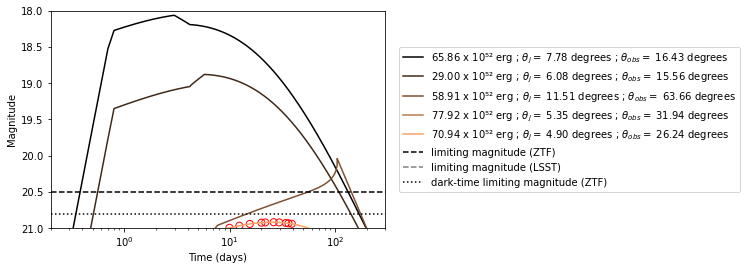

In [34]:
nu = 5*10**14

magZTF = 20.5
magLSST = 24


t = np.linspace(0.1,1000,10000)


for k in range(5):
    theta_j = np.random.uniform(3, 15)
    theta_obs = np.random.uniform(2,6)
    E = np.random.uniform(0.1, 100)
    mag=[]
    for i in t:
        if i < t_trans:
            mag.append(-2.5*np.log10((a(radians(theta_j),t_jet,theta_obs*radians(theta_j),i)**3*F_fast(a(radians(theta_j),t_jet,theta_obs*radians(theta_j),i)*i,nu,F_max,E))*10**(-29))-48.6)
        if i > t_trans:
            mag.append(-2.5*np.log10((a(radians(theta_j),t_jet,theta_obs*radians(theta_j),i)**3*F_slow(a(radians(theta_j),t_jet,theta_obs*radians(theta_j),i)*i,nu,F_max,E))*10**(-29))-48.6)
    plt.plot(t, mag, label = r'%.2f x 10⁵² erg ; $\theta_j = $ %.2f degrees ; $\theta_{obs} = $ %.2f degrees ' %(E, theta_j, theta_obs*theta_j), color=cm.copper(k/5))
    
t_init = np.random.uniform(0.01,10)
ti = [t_init]
    
for k in range(1,10):
    ti.append(ti[k-1] + random.gauss(3,1))
    
magi=[]
for i in ti:
    if i < t_trans:
        magi.append(-2.5*np.log10((a(radians(theta_j),t_jet,theta_obs*radians(theta_j),i)**3*F_fast(a(radians(theta_j),t_jet,theta_obs*radians(theta_j),i)*i,nu,F_max,E))*10**(-29))-48.6)
    if i > t_trans:
        magi.append(-2.5*np.log10((a(radians(theta_j),t_jet,theta_obs*radians(theta_j),i)**3*F_slow(a(radians(theta_j),t_jet,theta_obs*radians(theta_j),i)*i,nu,F_max,E))*10**(-29))-48.6)

for k in range(len(magi)):
    if magi[k] <= magZTF:
        plt.scatter(ti[k], magi[k], s=50, facecolors='none', edgecolors='black')
    elif magi[k] > magZTF:
        plt.scatter(ti[k], magi[k], s=50, facecolors='none', edgecolors='red')

plt.axhline(y=20.5, color='black', linestyle='--', label='limiting magnitude (ZTF)')
plt.axhline(y=24, color='grey', linestyle='--', label='limiting magnitude (LSST)')
plt.axhline(y=20.8, color='black', linestyle=':', label='dark-time limiting magnitude (ZTF)')

plt.xlabel('Time (days)')
plt.ylabel('Magnitude')
plt.xscale('log')
plt.xlim(0.2,300)
plt.ylim(18,21)
plt.gca().invert_yaxis()
plt.legend(bbox_to_anchor=(1.04,0.5), loc="center left", borderaxespad=0)

plt.savefig('simulation')
plt.show()

**Pre-selection :**

The plots of light curves and the simulations led us to establish some first criteria in order to make a pre-selection in the data. 
The criteria are the following :
- The magnitude must be higher than 18. Indeed, we can observe in the simulations that the magnitude is always higher than 18. An object with a magnitude lower could not be a candidate.
- We can expect 3 points in 10 days. In order to respect the shape of the light curve and given the distribution of the points, either the points decrease or the first and second ones increase and the third one decrease. Then, no selection is made on the first and second points but the third point have to be lower than the previous one. 
- For synchrotron emission, the difference between the magnitude of the g-band and the r-band remains constant and positive. It was calculated previously with the standard parameter and is equal to $0.34 \pm 0.01$. 
- Given the dimensions of the curve, there must be less than 1 month between the first and the last detection. 

**Ho, A., Perley, D., Beniamini, P., 2020 (https://arxiv.org/pdf/2006.10761.pdf)**

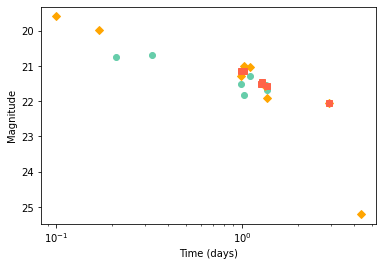

In [35]:
tg = [0.21,0.33,0.99,1.03,1.11,1.35,1.36]
tr = [0.10,0.17,0.99,1.03,1.11,1.33,1.37,2.93,4.35]
ti = [0.99,1.03,1.27,1.29,1.37,2.94]

g = [20.74,20.70,21.52,21.83,21.30,21.53,21.69]
r = [19.60,19.97,21.29,21.00,21.03,21.58,21.90,22.04,25.20]
i = [21.15,21.15,21.52,21.45,21.56,22.04]

plt.plot(tg,g,'o',color='mediumaquamarine')
plt.plot(tr,r,'D',color='orange')
plt.plot(ti,i,'s',color='tomato')


plt.xlabel('Time (days)')
plt.ylabel('Magnitude')
plt.xscale('log')
plt.gca().invert_yaxis()

In [36]:
import scipy.optimize as optimization

p0 = np.array([20.99, 2458876.69, 1.0, 0.52, 2.59, 4])

def mag(x, mc, t0, tb, a1, a2, n):
    return -2.5*np.log10(10**(-0.4*mc)*(((x-t0)**(a1*n)/tb)+((x-t0)**(a2*n)/tb)))**(-1/n)

print(optimization.curve_fit(mag, tr, r, p0))

(array([2.09900000e+01, 2.45887669e+06, 1.00000000e+00, 5.20000000e-01,
       2.59000000e+00, 4.00000000e+00]), array([[inf, inf, inf, inf, inf, inf],
       [inf, inf, inf, inf, inf, inf],
       [inf, inf, inf, inf, inf, inf],
       [inf, inf, inf, inf, inf, inf],
       [inf, inf, inf, inf, inf, inf],
       [inf, inf, inf, inf, inf, inf]]))


/tmp/ipykernel_202560/3628237807.py:6: RuntimeWarning: invalid value encountered in power
  return -2.5*np.log10(10**(-0.4*mc)*(((x-t0)**(a1*n)/tb)+((x-t0)**(a2*n)/tb)))**(-1/n)
/home/bregeon/data/Soft/miniconda3/envs/orphans/lib/python3.9/site-packages/scipy/optimize/minpack.py:833: OptimizeWarning: Covariance of the parameters could not be estimated
  warnings.warn('Covariance of the parameters could not be estimated',


/tmp/ipykernel_202560/1086353905.py:13: RuntimeWarning: invalid value encountered in double_scalars
  mag.append(-2.5*np.log10((10**(-0.4*mc)*(((i-t0)**(a1*n)/tb)+((i-t0)**(a2*n)/tb)))**(-1/n)))


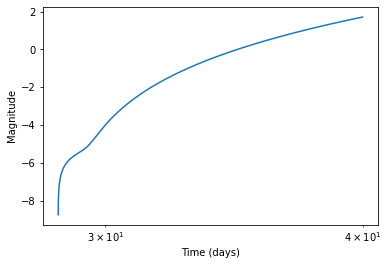

In [37]:
mc = 20.96
t0 = 2458876.68/(3600*24)
tb = 1.0
a1 = 0.54
a2 = 2.62
n = 4

t = np.linspace(0.01,40,10000)

mag = []

for i in t:
    mag.append(-2.5*np.log10((10**(-0.4*mc)*(((i-t0)**(a1*n)/tb)+((i-t0)**(a2*n)/tb)))**(-1/n)))


plt.plot(t, mag)
plt.xlabel('Time (days)')
plt.ylabel('Magnitude')
plt.xscale('log')

**To do :**
- Jouer avec le notebook : voir si dans les données, on peut avoir accès au temps entre la première et la dernière détection.
- Commencer à réfléchir au rapport et à la présentation de stage.

## References

- #### Articles 

Bellm, E., et al., 2019 (https://arxiv.org/pdf/1902.01932.pdf)

Granot, J., *et al.* 2002 *ApJ* **570** L61 (https://iopscience.iop.org/article/10.1086/340991/pdf)

Huang, Y., Urata, Y., Huang, K., *et al.*, 2020 (arXiv:2005.01730v2)

Ho, A., Perley, D., Beniamini, P., 2020 (https://arxiv.org/pdf/2006.10761.pdf)

Lamb, G., Kobayashi, S., 2017 (arXiv/1706.03000v2)

Nakar, E., Piran, T., Granot, J., 2002 (arXiv:astro-ph/0204203v4)

Sari, R., Piran, T., Narayan, R., 1997 (https://arxiv.org/abs/astro-ph/9712005v1)

Sari, R., Piran, T., Halpern, J. P., 1999 (https://iopscience.iop.org/article/10.1086/312109/pdf)

Zou, Y. C., Wu, X. F., Dai, Z. G., 2006 (https://arxiv.org/abs/astro-ph/0601292v2)

- #### Books

Rybicki, G., Ligthman, A., 1976 (http://www.bartol.udel.edu/~owocki/phys633/RadProc-RybLightman.pdf)

- #### Websites 

FINK Science Portal : http://134.158.75.151:24000/explorer

GCN Circulars Archive : https://gcn.gsfc.nasa.gov/gcn3_archive.html

Piran, T. : https://ned.ipac.caltech.edu/level5/March04/Piran/Piran_contents.html 

Useful Astronomical Data : http://www.astronomy.ohio-state.edu/~martini/usefuldata.html

ZTF : https://www.ztf.caltech.edu/

**Presentation on orphan afterglows at a FINK general meeting (30 june)**